In [7]:
##### ML model for downscaling capital intensities in the US 

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
# Get the current working directory
cd = Path.cwd().parent 

# Stage 1: train model

### Step 1: model set-up 

In [8]:
### prepare data

# load data
model_data = pd.read_csv(f"{cd}/Data/Misc./COMPS/USA_CAPITAL_MASTER.csv")

# set target and predictors 
target = 'log_capital_intensity_USD_per_USD'

predictors = [
    'pct_cropland_irrigated', 'average_travel_time_city',
    'average_travel_time_port', 'probability_economic_land_use_objective',
    'probability_survival_land_use_objective', 'GDP_pc',
    'USD_production_per_HA', 'cereals_share_production_USD',
    'fibres_share_production_USD', 'oilcrops_share_production_USD',
    'pulses_share_production_USD', 'roots_tubers_share_production_USD',
    'rest_of_crops_share_production_USD', 'sugar_crops_share_production_USD',
    'vegetables_share_production_USD', 'rubber_share_production_USD',
    'ruminants_share_production_USD', 'monogastrics_share_production_USD',
    'poultry_share_production_USD', 'share_vlarge_field',
    'share_large_field', 'share_small_field', 'share_vsmall_field'
]

In [9]:
### Set spatial blocks for CV
# 10 blocks = 5 states per block, for a 80/20 split 

n_folds = 10
states = model_data['STATE_ID'].unique()
np.random.seed(31)
np.random.shuffle(states)
state_folds = np.array_split(states, n_folds)  

In [11]:
### Parameters for grid-search 

grid_search = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features':     ['sqrt', 0.5, 0.75],
}

### Step 2: train model

In [12]:
# set lists to store results
metrics   = []
feature_importances = []

# run model for each fold, including grid search for each 
for fold_idx, test_states in enumerate(state_folds):
    print(f"Fold {fold_idx + 1}/{n_folds}")
    
    # split train and test for fold
    train_mask = ~model_data['STATE_ID'].isin(test_states)
    test_mask  =  model_data['STATE_ID'].isin(test_states)

    X_train = model_data.loc[train_mask, predictors]
    y_train = model_data.loc[train_mask, target]
    X_test  = model_data.loc[test_mask,  predictors]
    y_test  = model_data.loc[test_mask,  target]

    # train model - doing grid search for each fold
    # uses CV within each train dataset to determine 'best' model
    rf = RandomForestRegressor(random_state=27, n_jobs=-1)
    search = RandomizedSearchCV(
        rf, grid_search,
        n_iter=30,
        cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # evaluate models based on test data
    y_pred = best_model.predict(X_test)
    metrics.append({
        'fold':       fold_idx + 1,
        'best_params': search.best_params_,
        'RMSE':       np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE':        mean_absolute_error(y_test, y_pred),
        'R2':         r2_score(y_test, y_pred),
        'n_train':    len(y_train),
        'n_test':     len(y_test),
    })
    feature_importances.append(best_model.feature_importances_)
    print(f"  RMSE: {metrics[-1]['RMSE']:.4f}  MAE: {metrics[-1]['MAE']:.4f}  R²: {metrics[-1]['R2']:.4f}")


Fold 1/10 — test states: [np.int64(27), np.int64(1), np.int64(5), np.int64(17), np.int64(10)]
  RMSE: 0.4121  MAE: 0.2861  R²: 0.6626
Fold 2/10 — test states: [np.int64(53), np.int64(34), np.int64(21), np.int64(22), np.int64(30)]
  RMSE: 0.4836  MAE: 0.3724  R²: 0.6542
Fold 3/10 — test states: [np.int64(54), np.int64(8), np.int64(29), np.int64(41), np.int64(4)]
  RMSE: 0.5361  MAE: 0.4100  R²: 0.6014
Fold 4/10 — test states: [np.int64(16), np.int64(23), np.int64(13), np.int64(42)]
  RMSE: 0.5420  MAE: 0.3960  R²: 0.6352
Fold 5/10 — test states: [np.int64(47), np.int64(6), np.int64(37), np.int64(20)]
  RMSE: 0.5421  MAE: 0.4201  R²: 0.5848
Fold 6/10 — test states: [np.int64(28), np.int64(36), np.int64(18), np.int64(48)]
  RMSE: 0.3571  MAE: 0.2856  R²: 0.7085
Fold 7/10 — test states: [np.int64(19), np.int64(51), np.int64(25), np.int64(35)]
  RMSE: 0.3109  MAE: 0.2329  R²: 0.5953
Fold 8/10 — test states: [np.int64(40), np.int64(45), np.int64(56), np.int64(12)]
  RMSE: 0.5301  MAE: 0.3757

### Step 3: feature importance

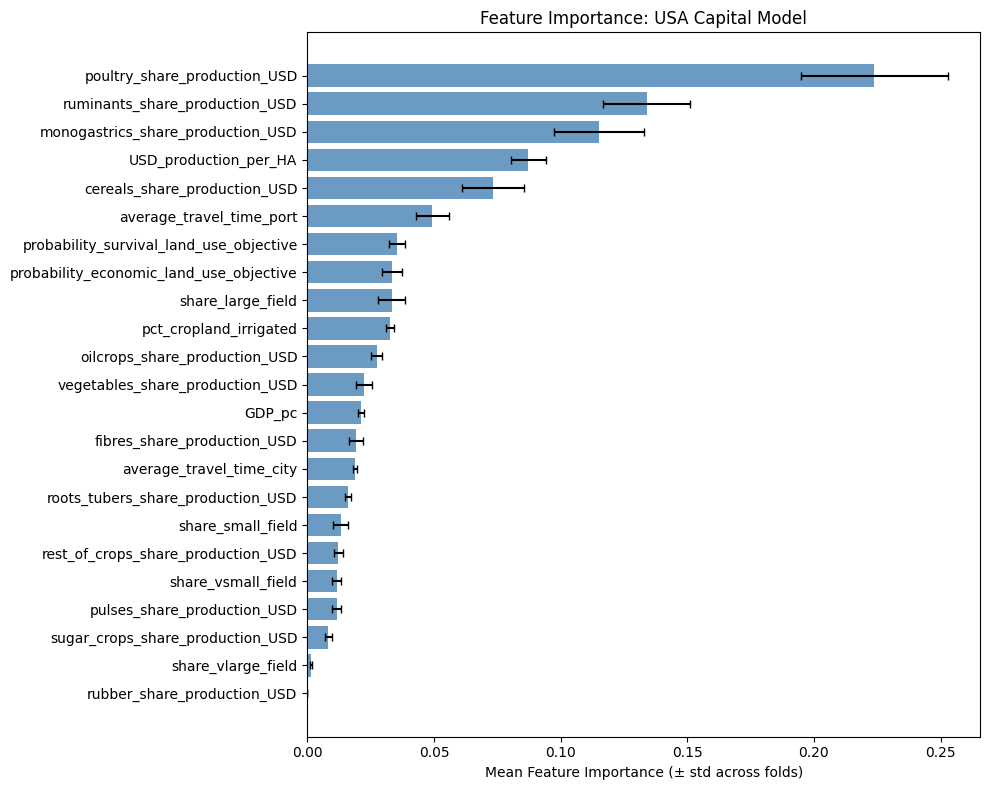

In [16]:
mean_importances = np.mean(feature_importances, axis=0)
std_importances  = np.std(feature_importances, axis=0)

importance_df = (
    pd.DataFrame({'feature': predictors, 'importance': mean_importances, 'std': std_importances})
    .sort_values('importance', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df['feature'], importance_df['importance'],
        xerr=importance_df['std'], capsize=3, color='steelblue', alpha=0.8)
ax.set_xlabel('Mean Feature Importance (± std across folds)')
ax.set_title('Feature Importance: USA Capital Model')
plt.tight_layout()
plt.show()